# PAD Avaliacao 02 - Regimes Territoriais de Transformacao

Este notebook aplica o enquadramento metodologico do **PROJETO DE PESQUISA DOIS**
ao fluxo principal do PAD. A estrategia continua baseada em uma camada longa,
auditavel e multigranular, mas o snapshot final passa a ser interpretado por meio de
**regimes territoriais de transformacao**, e nao mais por uma faixa unica de atencao.

Os artefatos publicos canonicos sao:

- `dados/saidas_finais/master_municipios_longo.csv`
- `dados/saidas_finais/master_municipios_analitico_snapshot.csv`

O objetivo analitico aqui e descritivo e comparativo: identificar combinacoes entre
intensificacao agropecuaria, dinamica demografica agregada e fragilidade educacional
rural, sem inferencia causal e sem modelagem preditiva.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_paths = [
    cwd / "notebooks",
    cwd,
    cwd.parent / "notebooks",
]
for candidate in candidate_paths:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))

from pad_avaliacao_02_pipeline import REGIME_VALUES, plotar_barras, run_pipeline

plt.style.use("seaborn-v0_8-whitegrid")
artifacts = run_pipeline(export=True)


## 1. Configuracao e checkpoints por fonte

Esta secao explicita o contrato da pipeline e resume a construcao da camada longa
antes de qualquer agregacao municipal final.


In [2]:
display(artifacts.configuracao)
display(artifacts.checkpoints_etl)


,parametro,valor
0,PROJECT_ROOT,/home/raimundoivy/Documents/pad_avaliação_02
1,CACHE_DIR,/home/raimundoivy/Documents/pad_avaliação_02/d...
2,LONG_OUTPUT,/home/raimundoivy/Documents/pad_avaliação_02/d...
3,ANALYTIC_OUTPUT,/home/raimundoivy/Documents/pad_avaliação_02/d...
4,BASE_YEAR,2006
5,SNAPSHOT_YEAR,2024
6,ANALYTIC_BASE_YEAR,2010


,dataset,linhas,colunas,anos_min,anos_max
0,populacao,105798,17,2006,2024
1,pam,154954,17,2006,2024
2,ppm,11134,17,2010,2024
3,censo_agro,16689,17,2017,2017
4,matriculas,61270,17,2024,2024
5,matriculas_cor_raca,83550,17,2024,2024
6,matriculas_tempo_jornada,61270,17,2024,2024
7,rendimento,3542076,17,2024,2024


## 2. Camada longa consolidada

Cada linha representa uma observacao tipificada por `fonte`, `dominio`,
`subdominio`, `indicador`, `unidade_medida` e `nivel_granularidade`.
A chave `chave_observacao` precisa ser unica.


In [3]:
display(artifacts.base_longa.head(10))
display(
    pd.DataFrame(
        [
            {"metrica": "linhas_base_longa", "valor": len(artifacts.base_longa)},
            {"metrica": "municipios_unicos", "valor": artifacts.base_longa["codigo_municipio"].nunique()},
            {"metrica": "subdominios_unicos", "valor": artifacts.base_longa["subdominio"].astype(str).nunique()},
            {"metrica": "chaves_unicas", "valor": artifacts.base_longa["chave_observacao"].nunique()},
        ]
    )
)


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
0,1100015,Alta Floresta D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,29005.0,municipio_x_ano_x_variavel_demografica,16359534587822696039
1,1100023,Ariquemes,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,86924.0,municipio_x_ano_x_variavel_demografica,13423775948061100541
2,1100031,Cabixi,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,7421.0,municipio_x_ano_x_variavel_demografica,10467845204708611676
3,1100049,Cacoal,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,76422.0,municipio_x_ano_x_variavel_demografica,9047006624870398846
4,1100056,Cerejeiras,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,17215.0,municipio_x_ano_x_variavel_demografica,800324718022644855
5,1100064,Colorado do Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,18342.0,municipio_x_ano_x_variavel_demografica,16786965487133790674
6,1100072,Corumbiara,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,9409.0,municipio_x_ano_x_variavel_demografica,189613597078291237
7,1100080,Costa Marques,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,11735.0,municipio_x_ano_x_variavel_demografica,17578391818067463668
8,1100098,Espigão D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,27559.0,municipio_x_ano_x_variavel_demografica,17173636992108112659
9,1100106,Guajará-Mirim,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,42082.0,municipio_x_ano_x_variavel_demografica,5959975388052928897


,metrica,valor
0,linhas_base_longa,4036741
1,municipios_unicos,5570
2,subdominios_unicos,9
3,chaves_unicas,4036741


## 3. Snapshot analitico derivado da base longa

O snapshot municipal e reconstruido exclusivamente a partir da camada longa.
Os sinais booleanos e o `regime_territorial` tornam explicita a heuristica
interpretativa adotada no projeto.


In [4]:
display(artifacts.snapshot_analitico.head(10))


,codigo_municipio,nome_municipio,sigla_estado,regiao,populacao_total_2010,populacao_total_2024,area_algodao_hectares_2010,area_algodao_hectares_2024,area_cana_hectares_2010,area_cana_hectares_2024,area_milho_hectares_2010,area_milho_hectares_2024,area_soja_hectares_2010,area_soja_hectares_2024,efetivo_bovino_2010,efetivo_bovino_2024,total_estabelecimentos_agricolas_2017,area_total_agricola_hectares_2017,num_tratores_2017,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,area_total_culturas_selecionadas_hectares_2024,variacao_populacao_2010_2024_pct,variacao_area_soja_2010_2024_pct,variacao_area_milho_2010_2024_pct,variacao_area_cana_2010_2024_pct,variacao_rebanho_bovino_2010_2024_pct,tratores_por_100_estabelecimentos_2017,hectares_por_estabelecimento_2017,matriculas_rurais_por_1000_hab_2024,percentil_area_culturas_2024,percentil_bovino_2024,escore_intensificacao_agropecuaria_2024,quartil_intensificacao_agropecuaria,porte_populacional_2024,sinal_intensificacao_agropecuaria,sinal_esvaziamento_demografico,sinal_fragilidade_educacional,regime_territorial
0,5107800,Santo Antônio de Leverger,MT,Centro-Oeste,18463.0,16795.0,0.0,2000.0,961.0,400.0,9400.0,30450.0,18754.0,40000.0,458011.0,549713.0,2382.0,925050.0,883.0,406.0,7.8,72850.0,-9.034285,113.287832,223.93617,-58.376691,20.02179,37.069689,388.350126,24.173861,0.963734,0.992639,0.978187,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
1,2110005,Santa Luzia,MA,Nordeste,74043.0,59037.0,0.0,0.0,10.0,0.0,22000.0,23500.0,0.0,13000.0,169941.0,358417.0,1961.0,261922.0,193.0,952.0,5.0,36500.0,-20.266602,<NA>,6.818182,-100.0,110.906726,9.841917,133.565528,16.125481,0.915889,0.98079,0.948339,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
2,2102325,Buriticupu,MA,Nordeste,65237.0,56896.0,0.0,0.0,20.0,0.0,14500.0,9350.0,0.0,41000.0,90424.0,172173.0,837.0,100739.0,105.0,912.0,7.5,50350.0,-12.785689,<NA>,-35.517241,-100.0,90.406308,12.544803,120.357228,16.029246,0.941652,0.947935,0.944794,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
3,1507300,São Félix do Xingu,PA,Norte,91340.0,65957.0,0.0,0.0,0.0,0.0,11462.0,10000.0,0.0,15000.0,2022366.0,2519911.0,6375.0,2462092.0,1306.0,808.0,12.5,25000.0,-27.789577,<NA>,-12.755191,<NA>,24.602124,20.486275,386.21051,12.250406,0.879533,1.0,0.939767,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
4,4319604,São Sepé,RS,Sul,23798.0,21575.0,0.0,0.0,10.0,10.0,2500.0,3130.0,27000.0,71700.0,143789.0,96071.0,1587.0,189743.0,1524.0,32.0,6.2,74840.0,-9.341121,165.555556,25.2,0.0,-33.186127,96.030246,119.560807,1.483198,0.965709,0.896768,0.931239,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
5,1713601,Monte do Carmo,TO,Norte,6716.0,5722.0,0.0,0.0,22.0,15.0,1540.0,21636.0,12000.0,52086.0,77100.0,95999.0,832.0,200395.0,244.0,49.0,8.5,73737.0,-14.800476,334.05,1304.935065,-31.818182,24.512322,29.326923,240.859375,8.563439,0.964452,0.896589,0.930521,Q4,ate_10_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
6,1508126,Ulianópolis,PA,Norte,43341.0,39576.0,0.0,0.0,9962.0,17000.0,5518.0,10700.0,9500.0,75500.0,76489.0,84613.0,1246.0,330144.0,422.0,154.0,6.5,103200.0,-8.686925,694.736842,93.910837,70.648464,10.621135,33.868379,264.963082,3.891247,0.974506,0.88474,0.929623,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
7,4302501,Bossoroca,RS,Sul,6884.0,5988.0,0.0,0.0,110.0,70.0,2500.0,3200.0,33000.0,55000.0,115914.0,96920.0,934.0,139114.0,615.0,28.0,22.2,58270.0,-13.015689,66.666667,28.0,-36.363636,-16.386286,65.845824,148.944325,4.676019,0.952065,0.897846,0.924955,Q4,ate_10_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
8,4315701,Rio Pardo,RS,Sul,37591.0,35666.0,0.0,0.0,20.0,15.0,4200.0,4000.0,23500.0,56370.0,123350.0,85000.0,2437.0,176824.0,1640.0,97.0,7.2,60385.0,-5.120907,139.87234,-4.761905,-25.0,-31.090393,67.295856,72.558063,2.719677,0.954578,0.885548,0.9200

## 4. Validacoes, exportacao e revisao amostral

Aqui verificamos integridade estrutural, cobertura minima dos dominios,
validade dos regimes e amostras auditaveis dos dois artefatos finais.


In [5]:
display(artifacts.validacoes)
display(artifacts.revisao_amostral.head(15))
display(artifacts.resumo_exportacao)


,checagem,valor
0,base_longa_codigos_com_7_digitos,True
1,snapshot_codigos_com_7_digitos,True
2,chave_observacao_unica,True
3,valor_numerico,True
4,unidade_medida_preenchida,True
5,fonte_preenchida,True
6,dominio_preenchido,True
7,base_longa_mais_de_4_milhoes,True
8,cobertura_dominios_minima,True
9,cobertura_subdominios_minima,True


,codigo_municipio,nome_municipio,ano_referencia,fonte,subdominio,indicador,produto_nome,localizacao,dependencia_administrativa,valor,fonte_amostra,sigla_estado,populacao_total_2024,area_soja_hectares_2024,efetivo_bovino_2024,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,regime_territorial
0,1100064,Colorado do Oeste,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Urbana,Municipal,5.3,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
1,1503804,Jacundá,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Urbana,Municipal,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
2,1504307,Maracanã,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Total,Pública,5.9,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
3,1703073,Barra do Ouro,2015.0,IBGE,populacao_municipal,populacao_total,NaN,NaN,NaN,4460.0,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
4,2109601,Rosário,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Rural,Estadual,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
5,2607802,Itaquitinga,2024.0,INEP,rendimento_escolar,taxa_abandono,NaN,Rural,Total,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
6,3103504,Araguari,2024.0,INEP,rendimento_escolar,taxa_aprovacao,NaN,Urbana,Pública,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
7,3136520,José Gonçalves de Minas,2024.0,INEP,matriculas_ensino_medio_tempo_jornada,matriculas,NaN,NaN,Estadual,0.0,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
8,3303005,Miracema,2024.0,INEP,rendimento_escolar,taxa_aprovacao,NaN,Urbana,Pública,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
9,5105606,Matupá,2024.0,INEP,rendimento_escolar,taxa_reprovacao,NaN,Rural,Estadual,<NA>,base_longa,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN


,artefato,gerado,linhas
0,master_municipios_longo.csv,True,4036741
1,master_municipios_analitico_snapshot.csv,True,5570


## 5. Estatistica descritiva, comparacoes e regimes territoriais

A leitura substantiva continua baseada em estatistica descritiva e comparacao
estruturada entre grupos, mas o produto sintese agora e uma tipologia de regimes
territoriais de transformacao.


,indicador,frequencia,media,mediana,minimo,maximo,amplitude,q1,q3
0,variacao_populacao_2010_2024_pct,5565,6.913831,4.385701,-48.909042,224.258871,273.167913,-2.746240,13.182904
1,variacao_area_soja_2010_2024_pct,1800,801.629833,104.263039,-100.000000,141876.000000,141976.000000,21.575648,389.166667
2,variacao_area_milho_2010_2024_pct,5176,157.330874,-33.333333,-100.000000,59900.000000,60000.000000,-72.222222,46.386134
3,variacao_area_cana_2010_2024_pct,3695,15.942123,-60.000000,-100.000000,28025.000000,28125.000000,-94.444444,0.000000
4,variacao_rebanho_bovino_2010_2024_pct,5523,11.845344,2.070521,-100.000000,2290.852850,2390.852850,-18.354013,27.367618
5,tratores_por_100_estabelecimentos_2017,4740,46.524272,29.262629,0.082327,1952.941176,1952.858849,6.522261,65.321055
6,hectares_por_estabelecimento_2017,5557,95.543768,42.824578,0.062500,5949.059701,5948.997201,20.712871,94.712329
7,matriculas_rurais_por_1000_hab_2024,5570,2.868194,0.000000,0.000000,121.070050,121.070050,0.000000,1.661556
8,taxa_abandono_rural_2024,1612,3.213275,1.500000,0.000000,60.700000,60.700000,0.000000,4.700000


,quartil_intensificacao_agropecuaria,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,tratores_por_100_estabelecimentos_2017
0,Q1,10.05,2.46,4.03,25.08
1,Q2,4.76,2.66,3.59,41.3
2,Q3,4.84,2.55,3.32,49.38
3,Q4,8.0,3.8,2.56,61.88


,regiao,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024
0,Centro-Oeste,12.62,3.31,1.43,0.81
1,Nordeste,4.19,2.98,4.3,0.41
2,Norte,12.11,9.08,4.23,0.58
3,Sudeste,6.79,1.54,2.0,0.46
4,Sul,7.0,2.04,2.7,0.54


,porte_populacional_2024,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024
0,ate_10_mil,2.08,1.8,2.94
1,10_a_50_mil,8.38,4.03,3.31
2,50_a_200_mil,19.31,3.12,3.16
3,acima_200_mil,19.21,0.79,3.27


,regime_territorial,municipios,participacao_pct,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024
0,intensificacao_com_esvaziamento_e_fragilidade,25,0.45,-9.95,9.35,9.52,0.87
1,intensificacao_com_fragilidade_educacional,58,1.04,17.44,10.99,8.86,0.85
2,intensificacao_com_adaptacao_relativa,261,4.69,18.1,7.33,1.13,0.88
3,baixa_pressao_territorial,1266,22.73,7.38,10.39,3.26,0.49
4,dados_insuficientes,3960,71.10,5.98,0.01,2.95,0.47


,variacao_populacao_2010_2024_pct,matriculas_rurais_por_1000_hab_2024,taxa_abandono_rural_2024,tratores_por_100_estabelecimentos_2017,hectares_por_estabelecimento_2017,escore_intensificacao_agropecuaria_2024
variacao_populacao_2010_2024_pct,1.000,0.025,0.061,0.131,0.122,-0.045
matriculas_rurais_por_1000_hab_2024,0.025,1.000,0.070,-0.097,0.016,0.063
taxa_abandono_rural_2024,0.061,0.070,1.000,-0.150,-0.034,-0.132
tratores_por_100_estabelecimentos_2017,0.131,-0.097,-0.150,1.000,0.452,0.201
hectares_por_estabelecimento_2017,0.122,0.016,-0.034,0.452,1.000,0.359
escore_intensificacao_agropecuaria_2024,-0.045,0.063,-0.132,0.201,0.359,1.000


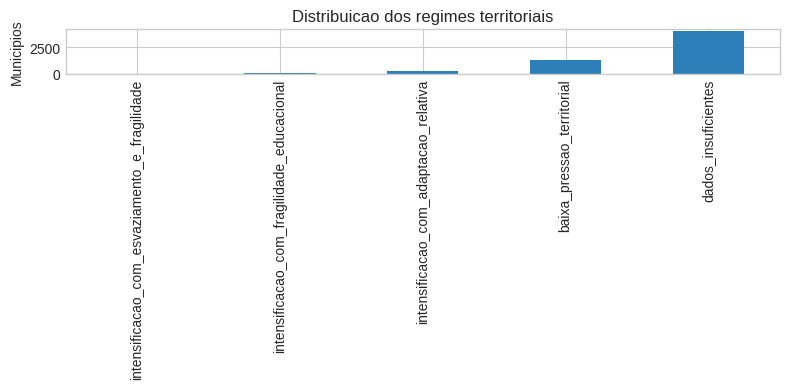

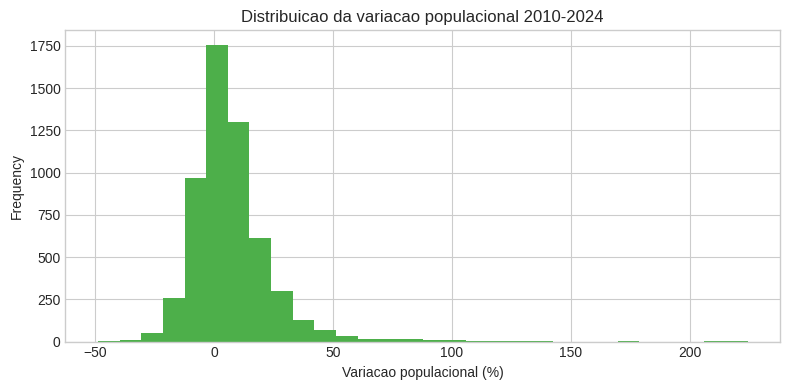

<Figure size 800x400 with 0 Axes>

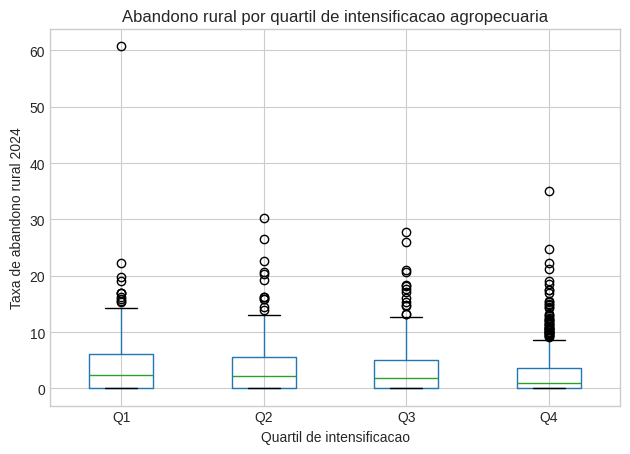

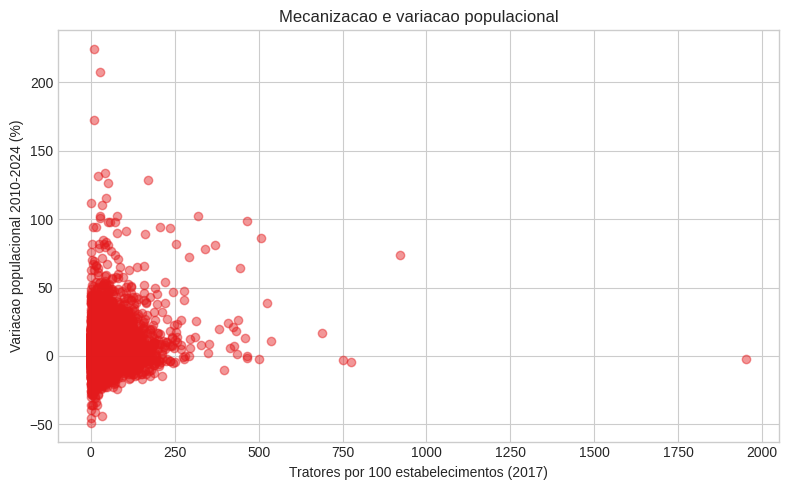

,regime_territorial,ordem_no_regime,codigo_municipio,nome_municipio,sigla_estado,regiao,sinal_intensificacao_agropecuaria,sinal_esvaziamento_demografico,sinal_fragilidade_educacional,variacao_populacao_2010_2024_pct,taxa_abandono_rural_2024,matriculas_rurais_por_1000_hab_2024,escore_intensificacao_agropecuaria_2024
0,intensificacao_com_esvaziamento_e_fragilidade,1,5107800,Santo Antônio de Leverger,MT,Centro-Oeste,True,True,True,-9.034285,7.8,24.173861,0.978187
1,intensificacao_com_esvaziamento_e_fragilidade,2,2110005,Santa Luzia,MA,Nordeste,True,True,True,-20.266602,5.0,16.125481,0.948339
2,intensificacao_com_esvaziamento_e_fragilidade,3,2102325,Buriticupu,MA,Nordeste,True,True,True,-12.785689,7.5,16.029246,0.944794
3,intensificacao_com_esvaziamento_e_fragilidade,4,1507300,São Félix do Xingu,PA,Norte,True,True,True,-27.789577,12.5,12.250406,0.939767
4,intensificacao_com_esvaziamento_e_fragilidade,5,4319604,São Sepé,RS,Sul,True,True,True,-9.341121,6.2,1.483198,0.931239
5,intensificacao_com_fragilidade_educacional,1,1502764,Cumaru do Norte,PA,Norte,True,False,True,42.719281,6.2,8.636272,0.982316
6,intensificacao_com_fragilidade_educacional,2,1100205,Porto Velho,RO,Norte,True,False,True,20.149489,11.4,1.64895,0.980341
7,intensificacao_com_fragilidade_educacional,3,4317103,Sant'Ana do Livramento,RS,Sul,True,False,True,5.859527,21.2,0.584219,0.979803
8,intensificacao_com_fragilidade_educacional,4,5000609,Amambai,MS,Centro-Oeste,True,False,True,19.245609,17.5,10.986623,0.978546
9,intensificacao_com_fragilidade_educacional,5,5007901,Sidrolândia,MS,Centro-Oeste,True,False,True,17.188835,12.8,10.65338,0.975583


In [6]:
display(artifacts.tabela_descritiva)
display(artifacts.comparacao_quartis)
display(artifacts.comparacao_regiao)
display(artifacts.comparacao_porte)
display(artifacts.resumo_regimes)
display(artifacts.matriz_correlacao)

regime_series = (
    artifacts.resumo_regimes.set_index("regime_territorial")["municipios"]
    .reindex(REGIME_VALUES)
    .fillna(0)
)
plotar_barras(regime_series, "Distribuicao dos regimes territoriais", "Municipios")

plt.figure(figsize=(8, 4))
artifacts.snapshot_analitico["variacao_populacao_2010_2024_pct"].dropna().plot.hist(
    bins=30,
    color="#4daf4a",
    title="Distribuicao da variacao populacional 2010-2024",
)
plt.xlabel("Variacao populacional (%)")
plt.tight_layout()
plt.show()

boxplot_df = artifacts.snapshot_analitico.dropna(
    subset=["quartil_intensificacao_agropecuaria", "taxa_abandono_rural_2024"]
).copy()
plt.figure(figsize=(8, 4))
boxplot_df.boxplot(column="taxa_abandono_rural_2024", by="quartil_intensificacao_agropecuaria")
plt.title("Abandono rural por quartil de intensificacao agropecuaria")
plt.suptitle("")
plt.xlabel("Quartil de intensificacao")
plt.ylabel("Taxa de abandono rural 2024")
plt.tight_layout()
plt.show()

scatter_df = artifacts.snapshot_analitico.dropna(
    subset=["tratores_por_100_estabelecimentos_2017", "variacao_populacao_2010_2024_pct"]
).copy()
plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_df["tratores_por_100_estabelecimentos_2017"],
    scatter_df["variacao_populacao_2010_2024_pct"],
    alpha=0.45,
    color="#e41a1c",
)
plt.title("Mecanizacao e variacao populacional")
plt.xlabel("Tratores por 100 estabelecimentos (2017)")
plt.ylabel("Variacao populacional 2010-2024 (%)")
plt.tight_layout()
plt.show()

display(artifacts.municipios_destaque_regime)


In [7]:
display(Markdown(artifacts.conclusao_markdown))



## 6. Conclusoes interpretativas

O artefato opera com base longa multigranular e interpreta o snapshot final por meio de regimes territoriais de transformacao, em chave descritiva e multicausal.

- Universo exportado na camada longa: **4,036,741 observacoes**.
- Universo do snapshot analitico: **5570 municipios**.
- Intensificacao com esvaziamento e fragilidade: **25** municipios.
- Intensificacao com fragilidade educacional: **58** municipios.
- Intensificacao com adaptacao relativa: **261** municipios.
- Baixa pressao territorial: **1266** municipios.
- Dados insuficientes: **3960** municipios.
- Associacao simples entre intensificacao agropecuaria e abandono rural: **-0.132**.
- Associacao simples entre intensificacao agropecuaria e variacao populacional: **-0.045**.

Municipios destacados nos regimes de maior pressao territorial observada:

- Santo Antônio de Leverger (MT)
- Santa Luzia (MA)
- Buriticupu (MA)
- São Félix do Xingu (PA)
- São Sepé (RS)

Limites metodologicos mantidos:

- sem aprendizado de maquina;
- sem previsao;
- sem inferencia causal;
- uso descritivo e comparativo;
- agregacao tardia derivada exclusivamente da base longa.
